# Step 0. 데이터 선택하기  
- 선택한 데이터: uci-secom.csv  
- 출처: https://www.kaggle.com/datasets/paresh2047/uci-semcom/code
- 실제 반도체 공정에서 수집된 591개의 센서 데이터와 그에 따른 공정 결과(성공/실패)로 구성된 데이터를 선택했다.  
- 해당 데이터의 특징은 하나의 제품의 생산과 관련된 특징이 매우 많다는 것이다.(591개)  
- 또한 각 센서의 명칭이 보안상 숫자로 대체되어있어, 정확히 어떤 센서 데이터인지 파악할 수 없다.  
- 그러나, 14:1에 달하는 극심한 데이터 불균형(정상이 불량보다 압도적으로 많음)과 590개가 넘는 다차원 변수를 처리하는 기술을 익히는 것은 좋은 경험이 될 것이라 생각하여, 해당 데이터를 선택했다.

## 0.1 데이터 불러오기  
- 데이터 분석에 필요한 여러 라이브러리를 불러오고, 'uci-secom.csv' 데이터를 'data' 변수에 할당하였다.  
- 또한 데이터의 크기를 확인하였다.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
data = pd.read_csv('uci-secom.csv')

# 데이터의 사이즈 확인
print(f"데이터 크기: {data.shape}\n")
data.head()

데이터 크기: (1567, 592)



,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [37]:
# 데이터 요약 정보 확인
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB
None


- 샘플 수는 1567개, 센서(칼럼)의 수는 592개인 것을 확인했다.
- 하나의 샘플을 구성하는 센서의 수가 매우 많으므로, 불필요한 칼럼 수를 줄이는 과정이 필요해보인다..

# Step 1. 데이터 기본 구조 파악

In [38]:
# 각 특성별 기초 통계량 확인
display(data.describe())

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


[데이터 해석]

- 데이터의 총 개수: 1,567개  
- count에서 1,567보다 작은 수 존재함. -> 결측치가 존재한다는 뜻.  
- count가 매우 작은 열? -> 데이터가 거의 수집되지 않은 '불량 센서'라는 뜻임.  
- std(표준편차)가 0인 경우 -> 모든 값이 같다는 뜻. 삭제 1순위 센서

# Step 2. 타겟 데이터 분포 확인  
Pass/Fail(-1: 정상, 1: 불량)의 비율 확인

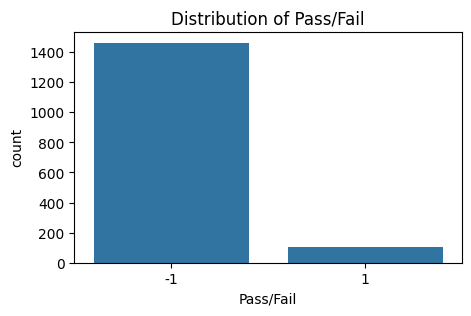

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64
정상:  1463 개
불량:  104 개
불량률: 6.64%


In [39]:
# Pass/Fail에 대한 비율을 seaborn의 막대그래프로 확인하기
plt.figure(figsize = (5, 3))
sns.countplot(x='Pass/Fail', data=data)
plt.title('Distribution of Pass/Fail')
plt.show()
print(data['Pass/Fail'].value_counts())

# 정확한 수치 확인하기
print("정상: ", data['Pass/Fail'].value_counts()[-1], "개") # 정상품의 개수
print("불량: ", data['Pass/Fail'].value_counts()[1], "개") # 불량품의 개수
print("불량률: {}%".format(round(data['Pass/Fail'].value_counts()[1] / len(data) * 100, 2))) # (불량품 / 전체) 의 비율

- 정상 샘플이 불량 샘플보다 압도적으로 많은 것을 확인할 수 있다.
- 추후 불량 샘플의 수를 가상으로 늘리는 과정이 필요해보인다.

# Step 3. 결측치 비율이 높은 상위 40개의 센서 확인


## 3.1 센서마다 결측치 비율(0~1)을 구하고, 가장 높은 값부터 상위 40개를 그래프로 나타내기

In [40]:
missing_probs = data.isnull().mean(axis=0) # 센서마다 결측치 개수의 평균(즉, 결측치 비율) 구하기
missing_probs = missing_probs[missing_probs > 0].sort_values(ascending=False) # 결측치 비율이 0보다 큰 센서에 대하여 내림차순 정렬
print(missing_probs)

292    0.911934
157    0.911934
158    0.911934
293    0.911934
492    0.855775
         ...   
585    0.000638
586    0.000638
587    0.000638
588    0.000638
589    0.000638
Length: 538, dtype: float64


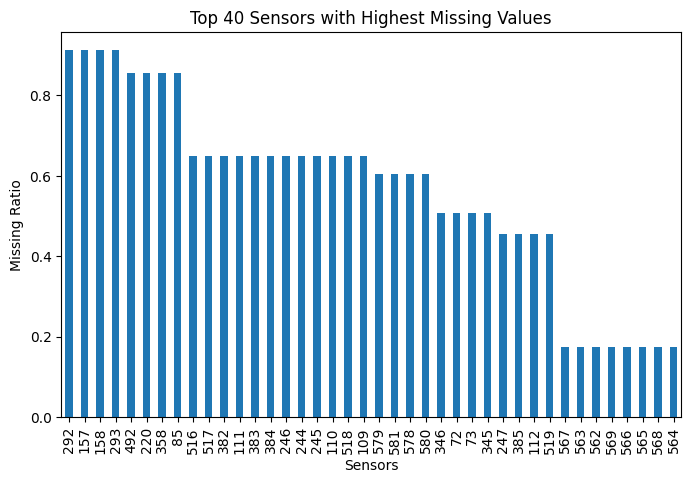

In [41]:
plt.figure(figsize = (8, 5)) # 그래프의 크기는 (8, 5)
missing_probs[:40].plot(kind = 'bar') # 결측치 비율 상위 40개의 데이터를 막대그래프로 표시
plt.title('Top 40 Sensors with Highest Missing Values')
plt.xlabel('Sensors')
plt.ylabel('Missing Ratio')
plt.show()

- 실제 공정에서는 결측치 비율이 0.5 이상인 센서는 불량 센서로 판단하여, 해당 센서를 삭제하고 데이터 분석을 하는 경우가 많다.

## 3.2 결측치 비율이 0.5 이상인 칼럼(센서) 제거

In [42]:
# data 변수에 저장된 각 칼럼별 결측치의 비율 계산
null_ratio = data.isnull().mean()

# 결측치 비율이 0.5 이상인 칼럼들의 이름 추출
columns_to_drop = null_ratio[null_ratio >= 0.5].index.tolist()

# 기존 'data' 자료에서 해당 칼럼을 제거한 새로운 데이터를 'data_cleaned_0'에 저장
data_cleaned = data.drop(columns=columns_to_drop, axis=1)

# 결과 확인
print(f"기존 칼럼 수: {data.shape[1]}개")
print(f"제거 대상 칼럼(결측치 50% 이상) 수: {len(columns_to_drop)}개")
print("-" * 30)
print(f"제거 후 남은 칼럼 수: {data_cleaned.shape[1]}개")

기존 칼럼 수: 592개
제거 대상 칼럼(결측치 50% 이상) 수: 28개
------------------------------
제거 후 남은 칼럼 수: 564개


# Step 4. 값이 변하지 않는 칼럼(분산=0) 제거

In [43]:
# 각 칼럼별로 고유한 값(Unique Value)의 개수 확인
unique_counts = data_cleaned.nunique()

# Unique Value 가 1인 칼럼들의 이름 추출
single_value_columns = unique_counts[unique_counts == 1].index.tolist()

# 해당 칼럼들을 제거하여 새로운 변수인 'data_final'에 저장
data_final = data_cleaned.drop(columns=single_value_columns, axis=1)

# 결과 확인
print(f"기존 칼럼 수: {data_cleaned.shape[1]}개")
print(f"제거 대상 칼럼(값이 변하지 않는 칼럼) 수: {len(single_value_columns)}개")
print("-" * 30)
print(f"제거 후 남은 칼럼 수: {data_final.shape[1]}개")

기존 칼럼 수: 564개
제거 대상 칼럼(값이 변하지 않는 칼럼) 수: 116개
------------------------------
제거 후 남은 칼럼 수: 448개


# Step 5. 각 칼럼(센서)와 타겟의 상관계수 계산
- 수 많은 센서 중 제품의 성공/실패 여부과 가장 연관있는 센서가 존재할 것이다. 해당 센서의 분포도를 그려보고 어떤 특징이 있는지 조사해보자.

## 5.1 타겟 칼럼과 다른 열과의 상관계수 확인

In [55]:
# 타겟 칼럼('Pass/Fail')과 다른 열과의 상관계수 확인
correlations = data_final.corr(numeric_only=True)['Pass/Fail'].sort_values(ascending=False)

# 타겟과 가장 상관관계가 높은 상위 20개의 센서 확인
# 상관계수의 절댓값이 큰 상위 20개의 센서를 출력
top_20_sensors = correlations.abs().sort_values(ascending=False).head(21)
print(f"상관계수가 높은 상위 20개의 센서:")
print(top_20_sensors)


상관계수가 높은 상위 20개의 센서:
Pass/Fail    1.000000
59           0.155796
103          0.151203
510          0.131593
348          0.130180
431          0.120851
434          0.112116
430          0.110067
435          0.109067
21           0.108488
28           0.107252
436          0.106910
129          0.103373
210          0.102545
298          0.102519
163          0.100330
124          0.093994
295          0.092249
160          0.090097
316          0.089412
164          0.088046
Name: Pass/Fail, dtype: float64


## 5.2 상관계수 상위 20개의 센서를 막대그래프로 나타내기

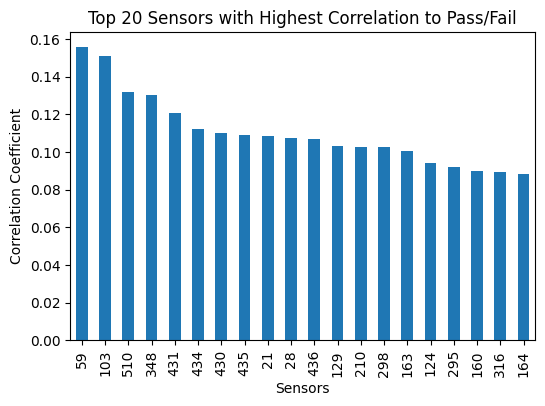

In [54]:
# 상위 20개의 센서를 막대 그래프로 나타내기
plt.figure(figsize=(6,4))
top_20_sensors[1:].plot(kind='bar')
plt.title('Top 20 Sensors with Highest Correlation to Pass/Fail')
plt.xlabel('Sensors')
plt.ylabel('Correlation Coefficient')
plt.show()

[수치 해석]  
- 양의 상관관계(+): 센서 값이 높아질수록 실패(혹은 성공) 확률이 높아지는 경우  
- 음의 상관관계(-): 센서 값이 낮아질수록 실패(혹은 성공) 확률이 높아지는 경우  
- 보통 상관계수의 값이 0.1 ~ 0.2 이상이 되면 공정 결과에 큰 영향을 주는 것으로 파악한다.  
- 반도체 데이터는 변수가 워낙 많이 때문에, 상관계수 값이 0.1만 넘어도 유의미하게 보기도 한다.

- 상관관계가 높은 센서들을 찾았으면, 그 다음은 센서들의 데이터 분포를 확인해야 한다.  
- 예를 들어서, "실패한 웨이퍼들은 특정 센서의 값이 유독 튀어 있는지?"를 확인할 수 있다.  
-> 즉, 이상치(Outiler) 확인

# Step 6. 이상치 확인

## 6.1 상관계수 상위 4개의 센서에 대해 박스플롯, KDE 플롯 그래프를 그려보기

/tmp/ipython-input-824/1315368021.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pass/Fail', y=sensor, data=data_final, ax=axes[i, 0], palette='Set2')
/tmp/ipython-input-824/1315368021.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pass/Fail', y=sensor, data=data_final, ax=axes[i, 0], palette='Set2')
/tmp/ipython-input-824/1315368021.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pass/Fail', y=sensor, data=data_final, ax=axes[i, 0], palette='Set2')
/tmp/ipython-input-824/1315368021.py:9: FutureWarning: 

Passing `pale

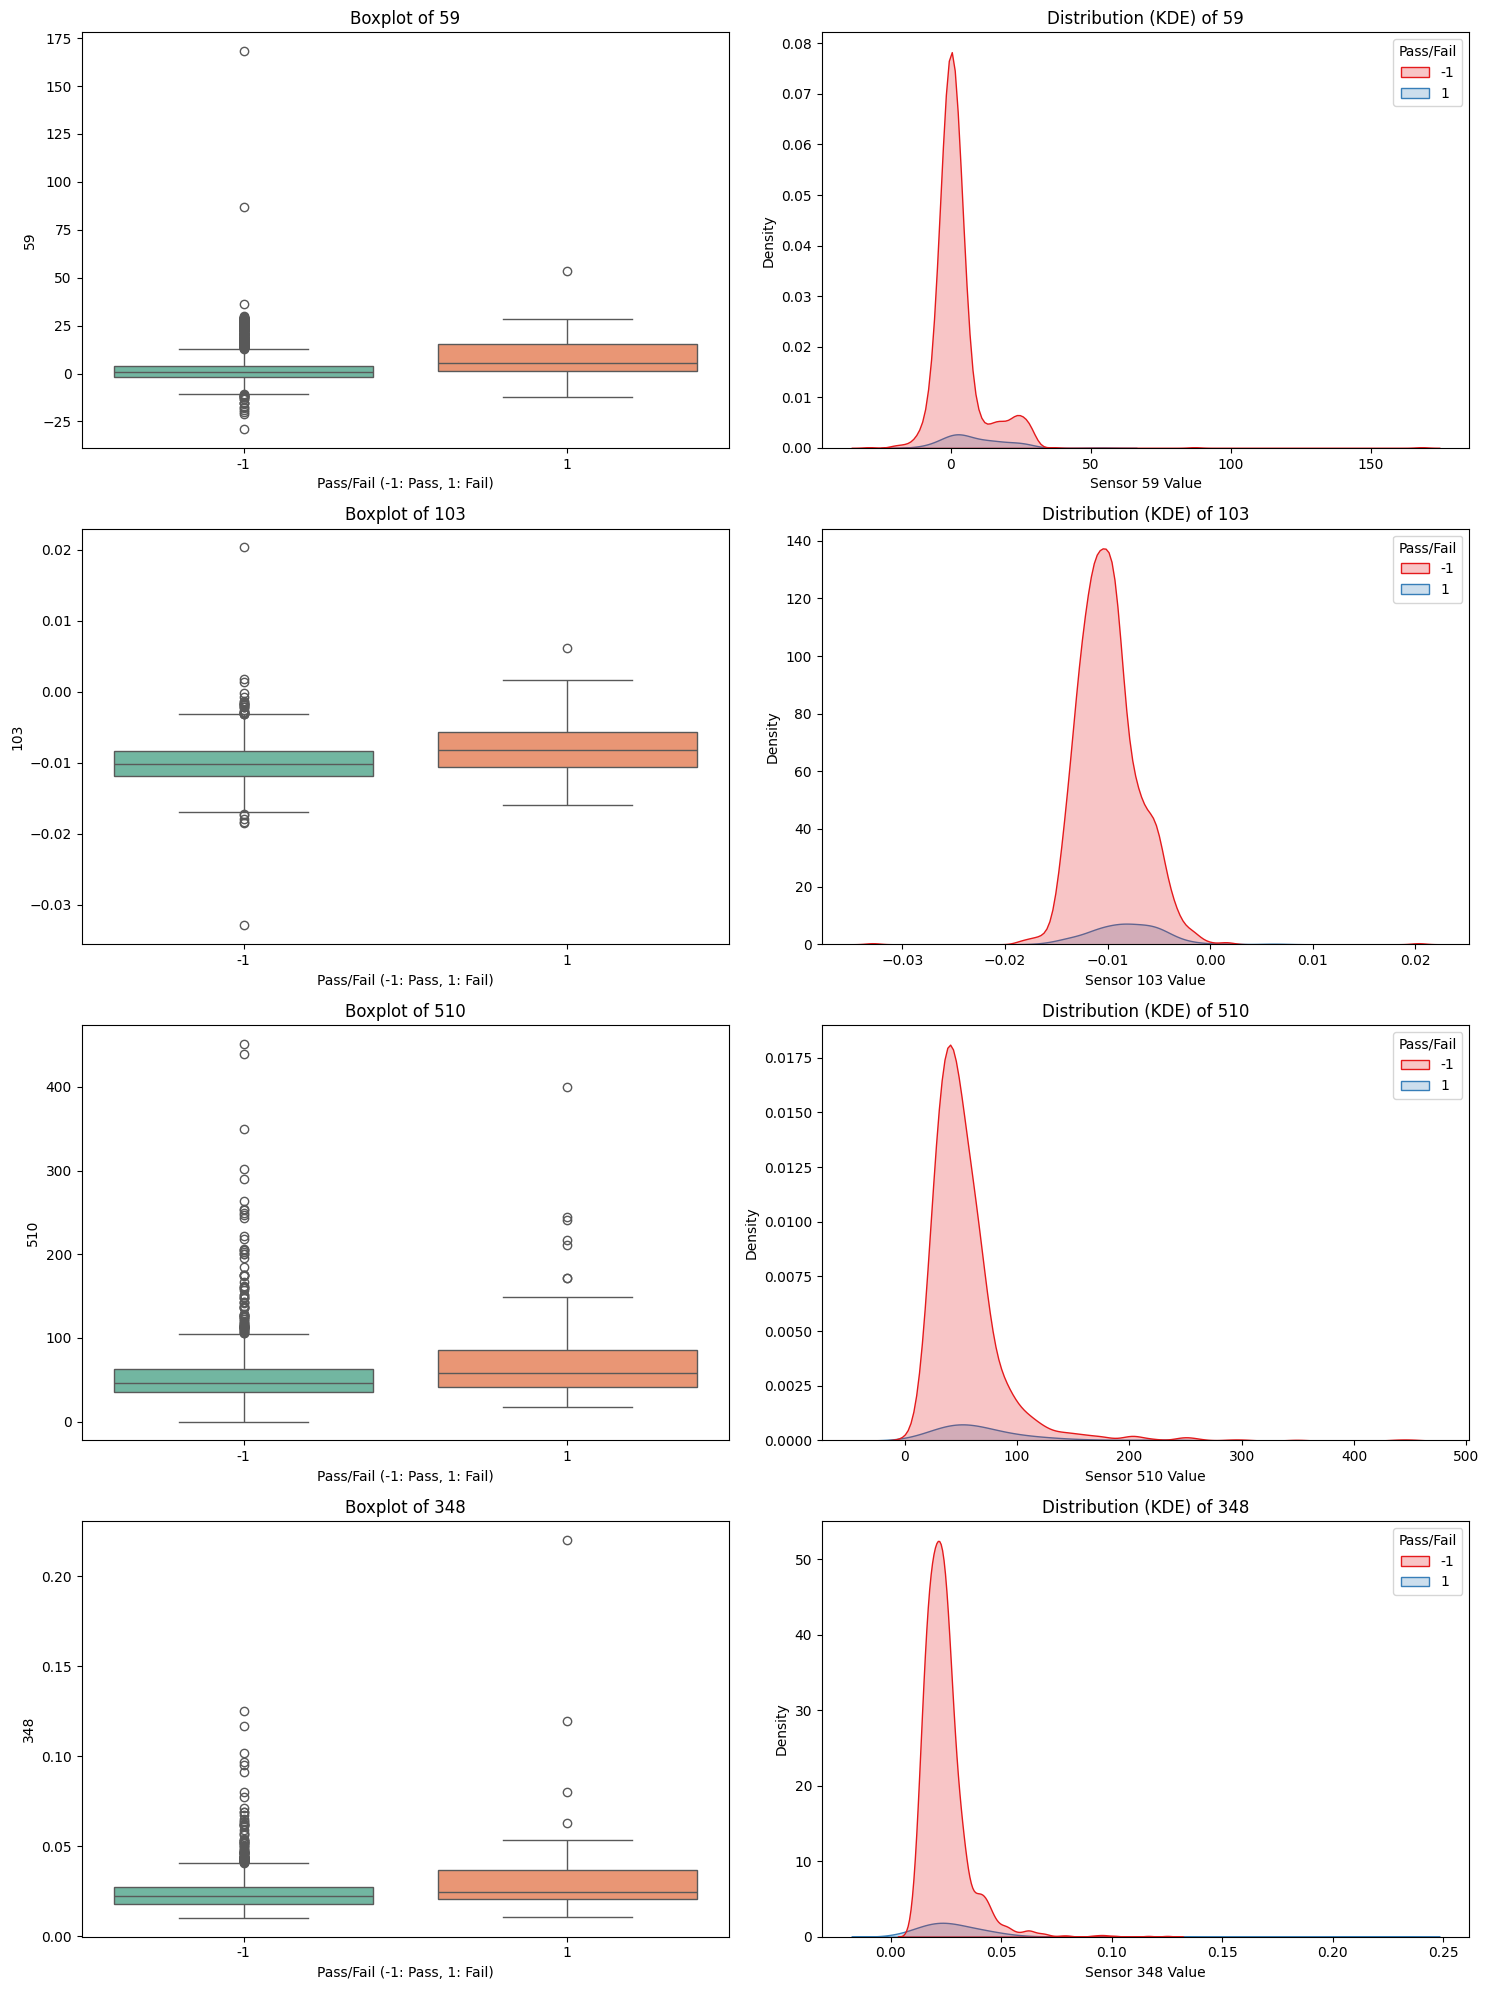

In [66]:
# 1. 분석할 핵심 센서 4개 선정
target_sensors = ['59', '103', '510', '348']

# 2. 그래프 영역 설정 (4행 2열 구조)
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

for i, sensor in enumerate(target_sensors):
    # 왼쪽: 박스 플롯 (중앙값과 이상치 확인용)
    sns.boxplot(x='Pass/Fail', y=sensor, data=data_final, ax=axes[i, 0], palette='Set2')
    axes[i, 0].set_title(f'Boxplot of {sensor}')
    axes[i, 0].set_xlabel('Pass/Fail (-1: Pass, 1: Fail)')

    # 오른쪽: KDE Plot (데이터의 밀도와 분포 모양 확인용)
    sns.kdeplot(data=data_final, x=sensor, hue='Pass/Fail', fill=True, ax=axes[i, 1], palette='Set1')
    axes[i, 1].set_title(f'Distribution (KDE) of {sensor}')
    axes[i, 1].set_xlabel(f'Sensor {sensor} Value')

plt.tight_layout()
plt.show()

## 6.2 그래프 해석  
- 센서 59 & 103: 박스플롯 그래프에서 성공 그룹과 실패 그룹의 박스 위치(중앙값)이 다르다. 실패 그룹의 수치가 성공 그룹보다 전반적으로 높게 형성되어 있다.  
결론: 59번과 103번 센서의 값이 일정 수준 이상으로 높아지면 불량이 발생할 확률이 매우 높다  

- 센서 510 & 348: 박스플롯 그래프에서 성공 그룹보다 실패 그룹의 박스가 더 넓은 경향이 있다. 즉, 값이 불안정하게 흔들릴 때 불량이 발생할 가능성이 있음을 시사한다.  

- 공통 포인트: 성공 그룹에서 값이 엄청나게 튀었는데도 성공한 케이스가 많다. 이는 단순히 "값이 크기 때문에 이상치다."라고 판단해서 데이터를 지워버리면 안된다는 뜻이다. 이러한 이상치들이 모델 학습에 방해가 될 수 있으므로, 추후 스케일링을 통해 이 값들의 영향을 줄여주는 작업이 필요해 보인다.

# Step 7. 결측치 채우기  
데이터에 남아있는 결측치들을 중앙값으로 채운다. Step 6에서 확인했듯이, 이상치가 많으면 평균값은 이에 크게 휘둘리기 때문에, 중앙값으로 채운다.

In [80]:
# 결측치를 채우기 전, 현재 데이터에 빈칸이 있는지 확인
print(f"[채우기 전] 총 결측치 개수: {data_final.isnull().sum(axis=0).sum()}")

# 각 칼럼의 중앙값(median) 계산
# 날짜 등의 데이터는 오류가 발생하므로, 숫자 데이터만 계산하기
columns_medians = data_final.median(numeric_only=True)

# 계산한 중앙값으로 결측치 채우기
data_final_imputed = data_final.fillna(columns_medians)

# 결과 확인
print(f"[채운 후] 총 결측치 개수: {data_final_imputed.isnull().sum(axis=0).sum()}")

[채우기 전] 총 결측치 개수: 10868
[채운 후] 총 결측치 개수: 0


# Step 8. 데이터 스케일링  
- 센서마다 값의 차이가 매우 크게 나므로, 스케일링을 진행해야 한다.
- 대표적인 스케일러는 StandardScaler, RobustScaler가 있지만 현재 데이터는 이상치(Outlier)가 많으므로 그에 적합한 RobustScaler를 사용한다.

In [92]:
# 사이킷런에서 스케일러 불러오기
from sklearn.preprocessing import RobustScaler

# 객체 할당
scaler = RobustScaler()

# 특성(x)과 타겟(y) 분리하기
# 'Pass/Fail'은 우리가 맞춰야 할 타겟(y)으로 분류한다.
# 'Time' 열은 숫자 데이터가 아니라 날짜이므로 제외한다.
x = data_final_imputed.drop(columns=['Pass/Fail', 'Time'])
y = data_final_imputed['Pass/Fail']

# 데이터 학습 및 변환
x_scaled = scaler.fit_transform(x)

# 결과를 데이터프레임으로 변환
x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)

# 결과 출력
print("날짜 데이터를 제외하고 데이터 스케일링 수행")
x_scaled_df.head(10)

날짜 데이터를 제외하고 데이터 스케일링 수행


,0,1,2,3,4,6,7,8,9,10,...,576,577,582,583,584,585,586,587,588,589
0,0.216300,0.752329,-0.360796,0.248699,0.086609,-0.591441,0.666667,0.368371,0.911458,-0.330435,...,0.105359,0.203070,0.067416,-0.408163,-0.1,-0.399261,0.000000,0.000000,0.000000,0.000000
1,0.937858,-0.399080,0.794346,0.352463,-0.972660,0.126073,0.851852,0.331439,0.041667,-1.321739,...,-1.049539,-0.522928,0.382022,1.734694,1.9,1.706763,-0.770318,0.546392,0.451613,1.936656
2,-0.877663,0.705043,-0.396574,0.815358,0.385951,-0.913868,0.629630,-0.170455,0.281250,0.078261,...,0.953703,-0.814754,-0.988764,0.387755,0.3,0.421721,2.678445,3.463918,3.290323,0.155719
3,-0.253352,-0.227172,-0.055023,-0.741524,0.007184,0.413291,-0.259259,0.251894,-0.578125,-0.321739,...,0.271502,-0.938245,-0.269663,-0.714286,-1.1,-0.711467,-0.021201,0.010309,-0.064516,0.027603
4,0.230876,0.040356,0.874023,0.081586,0.432249,-0.169215,0.407407,0.392992,-0.093750,-0.660870,...,0.071320,-0.510472,-4.539326,94.448980,100.9,97.673681,-0.021201,0.010309,-0.064516,0.027603
5,-0.725897,-0.775274,0.874023,0.081586,0.432249,-0.169215,0.407407,0.635417,0.937500,0.443478,...,0.087934,-0.007599,-1.191011,1.040816,0.8,1.082452,0.968198,0.030928,0.193548,-0.396311
6,0.208957,-0.806953,0.794346,0.352463,-0.972660,0.126073,0.851852,1.136364,-1.338542,0.878261,...,-0.868605,-0.977426,0.179775,0.102041,0.6,0.094947,0.968198,0.030928,0.193548,-0.396311
7,0.527288,2.221582,1.294347,-0.554521,-1.054480,0.717181,-1.444444,0.508523,0.885417,0.026087,...,111.038193,0.406553,-0.404494,-0.653061,-0.2,-0.638930,-0.007067,0.474227,0.548387,0.328646
8,-0.487455,1.177091,1.294347,-0.554521,-1.054480,0.717181,-1.444444,0.702652,0.645833,-0.608696,...,-0.607233,0.084472,-0.202247,0.693878,1.0,0.695989,-0.664311,-0.247423,-0.032258,0.564811
9,0.051405,-0.827335,1.294347,-0.554521,-1.054480,0.717181,-1.444444,0.724432,0.895833,0.391304,...,-1.946915,-1.147051,-0.786517,0.285714,0.2,0.314685,0.049470,0.443299,0.870968,0.260424


# Step 9. 다중공선성(Multicollinearity) 해결  
- 반도체 공정 특성상 여러 센서가 동일한 압력이나 온도를 측정하여 데이터가 서로 강한 상관관계를 가지는 경우가 발생한다.
- 중복된 정보는 모델을 복잡하게 만들고 해석을 어렵게 하므로, 상관계수가 0.9 이상인 센서들 중 하나만 남기고 삭제한다.

In [121]:
# 센서 간 상관계수 행렬 계산(절댓값)
# 현재 남아있는 센서는 446개이기 때문에, 행렬의 크기는 446 x 446 임.
corr_matrix = x_scaled_df.corr().abs()

# 중복 계산을 방지하기 위해 상삼각 행렬(Upper triangle)만 선택
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 상관계수가 0.9 넘는 칼럼 찾기
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# 해당 칼럼들 제거하기
x_final = x_scaled_df.drop(columns=to_drop)

print("[상관계수가 0.9 이상인 칼럼 제거]")
print(f"기존 칼럼 수: {x_scaled_df.shape[1]}개")
print(f"상관계수가 0.9 이상인 칼럼 수: {len(to_drop)}개")
print("-" * 40)
print(f"남은 칼럼 수: {len(x_final.columns)}개")

[상관계수가 0.9 이상인 칼럼 제거]
기존 칼럼 수: 446개
상관계수가 0.9 이상인 칼럼 수: 196개
----------------------------------------
남은 칼럼 수: 250개


# Step 10. SMOTE 기법을 이용한 데이터 불균형 해소  
- 현재 데이터는 '성공'이 압도적으로 많다. 이 상태로 모델을 학습하면 모델이 무조건 '성공'이라고 예측하는 편향이 발생할 수 있다. SMOTE(Synthetic Minority Over-sampling Technique) 기법은 부족한 '실패' 데이터를 수학적으로 생성하여 성공 데이터와 실패 데이터의 비율을 맞춰주는 기법이다.   
- 현재 정상 데이터는 1463 개, 불량 데이터는 104 개이다. 불량의 비율은 약 6%이므로 이를 30%로 우선 늘려 모델을 학습하고, 성능을 더 높일 필요성이 생기면 50%를 거쳐 100%까지 늘려보는 전략을 세웠다.

In [158]:
# SMOTE 를 위해 imbalanced-learn 라이브러리 불러오기
from imblearn.over_sampling import SMOTE

# SMOTE 객체 생성, 랜덤 시드는 42
# 초기 접근: 불량(1) 데이터를 정상(-1) 데이터의 30% 수준까지 생성해본다.
# 추후 sampling_strategy의 비율을 1까지 올려 성공과 실패의 비율을 1:1로 맞출 예정이다.
smote = SMOTE(sampling_strategy=0.3, random_state=42)

# 실패 데이터 생성
x_resampled, y_resampled = smote.fit_resample(x_final, y)

print(f"[SMOTE 전]\n실패 데이터: {len(y[y == 1])}개\n성공 데이터: {len(y[y == -1])}개\n전체 데이터 중 실패 데이터 비율: {np.round(len(y[y == 1]) / len(y) * 100, 2)}%\n")
print(f"[SMOTE 후]\n실패 데이터: {len(y_resampled[y_resampled == 1])}개\n성공 데이터: {len(y_resampled[y_resampled == -1])}개\n전체 데이터 중 실패 데이터 비율: {np.round(len(y_resampled[y_resampled == 1]) / len(y_resampled) * 100, 2)}%")

[SMOTE 전]
실패 데이터: 104개
성공 데이터: 1463개
전체 데이터 중 실패 데이터 비율: 6.64%

[SMOTE 후]
실패 데이터: 438개
성공 데이터: 1463개
전체 데이터 중 실패 데이터 비율: 23.04%


# Step 11. 데이터 최종 타입 확인  
- 이전 Step에서 '날짜' 데이터는 에러가 발생한 것을 확인했다. 이처럼 혹시라도 숫자가 아닌 문자열(Object) 칼럼이 남아있는지 확인해야 한다. 만약 남아있다면 모델이 계산을 못하고 에러를 발생시킬 것이다.

In [154]:
# 숫자가 아닌 칼럼이 남아있는지 확인
non_numeric_final = x_resampled.select_dtypes(exclude=[np.number]).columns
print(f"남아있는 비숫자 칼럼: {non_numeric_final}")

남아있는 비숫자 칼럼: Index([], dtype='object')


# Step 12. 레이블 인코딩  
- 현재 타겟(y_resampled) 값은 정상(-1), 불량(1)로 되어있다. 최신 머신러닝 알고리즘(XGBoost 등) 은 정답 레이블이 0부터 시작하는 양수여야만 동작하는 경우가 있기에, 정상을 -1에서 0으로 변경한다.

In [155]:
# -1을 0으로 변경
y_final = y_resampled.replace({-1: 0})
print(f"레이블 변경 확인: {y_final.value_counts()}")

레이블 변경 확인: Pass/Fail
0    1463
1     438
Name: count, dtype: int64


여기까지 기본적인 EDA를 마치며, 추후 모델 학습을 진행할 예정이다.